# Proiect Big Data


**Universitatea din București**

**Facultatea de Matematică și Informatică**

**Master BDTS IFR**

**Semestrul 2 - 2025**


**Matei Mîndruleanu** 

---



# Cuprins

1. Introducere  
   1.1. Prezentarea setului de date  
   1.2. Obiectivele proiectului  

2. Procesarea datelor în Spark  
   2.1. Importul și afișarea datelor  
   2.2. Structura DataFrame-ului  
   2.3. Curățarea datelor  
   2.4. Statistici descriptive  
   2.5. Medii pe cultură  

3. Învățare automată cu Spark MLlib  
   3.1. Logistic Regression  
   3.2. Decision Tree  
   3.3. Random Forest  
   3.4. Comparație rezultate  

4. Utilizarea unui Pipeline în MLlib  


cuprinsul generat este prezent în notebook :)


# Introducere

## 1. Prezentarea setului de date

Setul de date utilizat în acest proiect este **Crop Recommendation Dataset**, descărcat de pe platforma Kaggle:
🔗 https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset

Acest set de date conține **2200 de intrări**, fiecare caracterizată prin 7 atribute:
- `N`, `P`, `K` – conținutul de azot, fosfor și potasiu în sol
- `temperature` – temperatura medie (°C)
- `humidity` – umiditatea relativă (%)
- `ph` – nivelul de aciditate/alcalinitate al solului
- `rainfall` – cantitatea de precipitații (mm)

Coloana `label` reprezintă cultura recomandată pe baza acestor caracteristici (ex: rice, maize, lentil, etc.).

---

## 2. Obiectivele proiectului

Scopul proiectului este de a analiza și modela acest set de date folosind **Apache Spark** pentru a:
1. Prelucra și curăța datele cu Spark SQL și DataFrame API
2. Calcula statistici și agregări utile (ex: valori medii pe culturi)
3. Aplica metode de învățare automată (MLlib) pentru a prezice cultura optimă
4. Evalua performanța mai multor modele de clasificare și justifica alegerea finală



# Procesarea datelor în Spark

### Ce facem:
- Încărcăm fișierul .csv
- Verificăm schema și primele rânduri
- Eliminăm duplicate
- Verificăm valori lipsă
- Calculăm statistici descriptive
- Grupăm după cultură
- Interogăm folosind SQL


In [1]:
from pyspark.sql import SparkSession

# initializam o sesiune spark
spark = SparkSession.builder.appName("CropRecommendation").getOrCreate()

# citim fisierul CSV (cu antet si tipuri detectate automat)
df = spark.read.csv("crop_recommendation.csv", header=True, inferSchema=True)

# afisam schema(structura coloanelor)
df.printSchema()

# afisam primele 5 randuri
df.show(5)

root
 |-- N: integer (nullable = true)
 |-- P: integer (nullable = true)
 |-- K: integer (nullable = true)
 |-- temperature: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- ph: double (nullable = true)
 |-- rainfall: double (nullable = true)
 |-- label: string (nullable = true)

+---+---+---+-----------+-----------+-----------------+-----------+-----+
|  N|  P|  K|temperature|   humidity|               ph|   rainfall|label|
+---+---+---+-----------+-----------+-----------------+-----------+-----+
| 90| 42| 43|20.87974371|82.00274423|6.502985292000001|202.9355362| rice|
| 85| 58| 41|21.77046169|80.31964408|      7.038096361|226.6555374| rice|
| 60| 55| 44|23.00445915| 82.3207629|      7.840207144|263.9642476| rice|
| 74| 35| 40|26.49109635|80.15836264|      6.980400905|242.8640342| rice|
| 78| 42| 42|20.13017482|81.60487287|      7.628472891|262.7173405| rice|
+---+---+---+-----------+-----------+-----------------+-----------+-----+
only showing top 5 rows


In [2]:

# Verificam numarul total al randurilor
print("Total rows initial:", df.count())

# eliminam randurile duplicate(daca exista)
df_clean = df.dropDuplicates()

# verificam numarul randurilor dupa curatare
print("Total rows after deleting duplicates:", df_clean.count())


Total rows initial: 2200
Total rows after deleting duplicates: 2200


In [3]:

from pyspark.sql.functions import col, avg, count, isnan, isnull, when

# verificam cate valori lipsesc (null sau NaN) pe fiecare coloana
df_clean.select([
    count(when(isnull(c) | (isnan(c) if df_clean.schema[c].dataType.simpleString() != 'string' else False), c)).alias(f"{c}_nulls")
    for c in df_clean.columns
]).show()

+-------+-------+-------+-----------------+--------------+--------+--------------+-----------+
|N_nulls|P_nulls|K_nulls|temperature_nulls|humidity_nulls|ph_nulls|rainfall_nulls|label_nulls|
+-------+-------+-------+-----------------+--------------+--------+--------------+-----------+
|      0|      0|      0|                0|             0|       0|             0|          0|
+-------+-------+-------+-----------------+--------------+--------+--------------+-----------+



In [4]:

# Statistici clasice: count, mean, stddev, min, max
# count - nr randuri pe coloana, mean - media aritmetica a valorilor, 
# stddev - raspandirea valorilro fata de medie, daca toti indivizii au aceeasi valoare atunci stddev va fi 0, 
# cu cat sunt valorile mai raspandite cu atat va fi si acesta mai mare 
# min - cea mai mica valoare din coloana, max - cea mai mare valoare din coloana
df_clean.describe().show()


+-------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+----------+
|summary|                 N|                 P|                K|       temperature|          humidity|                ph|          rainfall|     label|
+-------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+----------+
|  count|              2200|              2200|             2200|              2200|              2200|              2200|              2200|      2200|
|   mean|50.551818181818184| 53.36272727272727|48.14909090909091|25.616243851779597| 71.48177921778648| 6.469480065256371|103.46365541576814|      NULL|
| stddev| 36.91733383375661|32.985882738587115|50.64793054666017| 5.063748599958843|22.263811589761065|0.7739376880298733| 54.95838852487805|      NULL|
|    min|                 0|                 5|                5|       8.82567474

In [5]:

# Calculăm medii pe fiecare cultură (label)
df_clean.groupBy("label").agg(
    avg("N").alias("avg_N"),
    avg("P").alias("avg_P"),
    avg("K").alias("avg_K"),
    avg("temperature").alias("avg_temp"),
    avg("humidity").alias("avg_humid"),
    avg("ph").alias("avg_ph"),
    avg("rainfall").alias("avg_rain")
).orderBy("label").show()


+-----------+------+------+------+------------------+-----------------+------------------+------------------+
|      label| avg_N| avg_P| avg_K|          avg_temp|        avg_humid|            avg_ph|          avg_rain|
+-----------+------+------+------+------------------+-----------------+------------------+------------------+
|      apple|  20.8|134.22|199.89| 22.63094241320001|92.33338287559998| 5.929662931809998|112.65477927500002|
|     banana|100.23| 82.01| 50.05|27.376798305699996|80.35812258109999| 5.983893180240002|104.62698040009998|
|  blackgram| 40.02| 67.47| 19.24| 29.97333967889999|    65.1184255887|7.1339516294799985| 67.88415118319999|
|   chickpea| 40.09| 67.79| 79.92| 18.87284675190001|    16.8604394237|     7.33695662374|     80.0589772605|
|    coconut| 21.98| 16.93| 30.59|27.409892172300005|94.84427180610001| 5.976562126190001|175.68664580399997|
|     coffee| 101.2| 28.74| 29.94|25.540476819300007|58.86984630029999| 6.790308274570005|158.06629488199994|
|     cott

In [6]:
# inregistram dataframe-ul ca tabel temporar
df_clean.createOrReplaceTempView("crops")

# selectam doar culturile care au ph mediu > 7
spark.sql("""
    SELECT label, ROUND(AVG(ph), 2) as avg_ph
    FROM crops
    GROUP BY label
    HAVING avg_ph > 7
""").show()


+---------+------+
|    label|avg_ph|
+---------+------+
| chickpea|  7.34|
|   orange|  7.02|
|blackgram|  7.13|
+---------+------+



# Învățare automată cu Spark MLlib

Scopul acestei etape este de a folosi tehnici de învățare automată (machine learning) pentru a antrena un model care, pe baza caracteristicilor solului și ale climei, poate recomanda automat ce cultură agricolă este optimă pentru un anumit context.

Pentru acest lucru, folosim biblioteca **Spark MLlib**, care oferă unelte eficiente pentru preprocesarea datelor, antrenarea modelelor și evaluarea performanței acestora, chiar și pe volume mari de date.

---

## Ce vom face în acest capitol:

1. **Pregătirea datelor** pentru modelele ML:
   - Conversia etichetei (`label`) din text în număr (ex: rice → 0, maize → 1, etc.)
   - Combinarea tuturor caracteristicilor într-un singur vector (`features`)

2. **Împărțirea datelor** în set de antrenare (train) și set de testare (test)

3. **Antrenarea a 3 modele de clasificare**:
   - Logistic Regression
   - Decision Tree Classifier
   - Random Forest Classifier

4. **Evaluarea performanței** fiecărui model prin metrica de acuratețe (`accuracy`)

La finalul acestui capitol vom putea spune care model este cel mai eficient în predicția culturii potrivite și de ce.



In [7]:
# Pregatirea datelor
# transformam datele in formatul necesar pentru a fi folosite de algoritmii de ml

from pyspark.ml.feature import StringIndexer, VectorAssembler

# convertim coloana label din string in numeric -> index
indexer = StringIndexer(inputCol="label", outputCol="labelIndex")
df_indexed = indexer.fit(df_clean).transform(df_clean)

# combinam toate coloanele intr-un singur vector "featur
assembler = VectorAssembler(
    inputCols=["N", "P", "K", "temperature", "humidity", "ph", "rainfall"],
    outputCol="features"
)

df_features = assembler.transform(df_indexed)

# 3. afisam primele 5 randuri pentru verificarea coloanelor noi
df_features.select("features", "label", "labelIndex").show(5, truncate=False)


+----------------------------------------------------------------+----------+----------+
|features                                                        |label     |labelIndex|
+----------------------------------------------------------------+----------+----------+
|[36.0,76.0,75.0,18.38120357,16.63805158,8.736337905,70.52056697]|chickpea  |3.0       |
|[3.0,68.0,16.0,18.31910448,34.69776639,4.964887857,107.4721605] |pigeonpeas|18.0      |
|[14.0,55.0,15.0,27.33580911,55.27755933,8.050304395,73.44775287]|mothbeans |13.0      |
|[6.0,48.0,24.0,28.6362812,84.61431076,6.790736339,48.48319335]  |mungbean  |14.0      |
|[53.0,74.0,15.0,29.43463808,64.94329356,7.517097,72.17818157]   |blackgram |2.0       |
+----------------------------------------------------------------+----------+----------+
only showing top 5 rows


In [14]:
# Impartirea datelor in train si test
# impartim setul in date train (80%) si test (20%)
# folosim seed = 1 ca sa generezez la fel listele de fiecare data(la fiecare rulare)
train_data, test_data = df_features.randomSplit([0.8, 0.2], seed=1)

# verificam cate randuri avem in fiecare set
print("Rânduri în setul de antrenare:", train_data.count())
print("Rânduri în setul de testare:", test_data.count())


Rânduri în setul de antrenare: 1773
Rânduri în setul de testare: 427


### Metoda 1 – Logistic Regression
Transformă datele în probabilități și alege clasa cu șansa cea mai mare. E rapid și bun pentru clasificări clare.

#### Enunțul problemei:
Dorim să antrenăm un model de clasificare care, pe baza valorilor solului și ale condițiilor climatice (N, P, K, temperature, humidity, ph, rainfall), să recomande automat ce cultură agricolă este potrivită (ex: rice, maize, apple, etc.).

#### Justificarea alegerii metodei:
Am ales Logistic Regression ca primă metodă deoarece este:
- Un algoritm simplu, eficient și interpretabil
- Potrivit pentru clasificare multi-clasă
- Rapid la antrenare și oferă o bază bună de comparație cu alte metode mai complexe

#### Soluția tehnică:
- Vom antrena modelul folosind coloanele features (care conțin valorile solului) pentru a prezice labelIndex
- Vom evalua modelul pe datele de test și vom calcula acuratețea (accuracy)


In [9]:

from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# definim modelul
lr = LogisticRegression(featuresCol='features', labelCol='labelIndex')

# antrenam modelul pe setul de train
lr_model = lr.fit(train_data)

# facem predictii pe setul de test
lr_predictions = lr_model.transform(test_data)

# evaluam acuratetea modelului
evaluator = MulticlassClassificationEvaluator(
    labelCol="labelIndex", predictionCol="prediction", metricName="accuracy"
)
lr_accuracy = evaluator.evaluate(lr_predictions)

# printam rezultatele
print("Acuratețea modelului Logistic Regression:", round(lr_accuracy, 4))

Acuratețea modelului Logistic Regression: 0.9766


### Metoda 2 – Decision Tree Classifier
Pune întrebări de tip „DA/NU” pentru a decide ce clasă se potrivește. Funcționează ca un test logic.

#### Enunțul problemei:
Dorim să antrenăm un model de clasificare care, pe baza valorilor solului și ale condițiilor climatice (N, P, K, temperature, humidity, ph, rainfall), să recomande automat ce cultură agricolă este potrivită (ex: rice, maize, apple, etc.).

#### Justificarea alegerii metodei:
Am ales Decision Tree deoarece:
- Este ușor de înțeles: modelul poate fi interpretat ca un set de reguli „dacă... atunci...”
- Se potrivește bine cu datele noastre numerice
- Nu are nevoie de scalare a datelor
- Poate gestiona ușor probleme de clasificare multi-clasă

#### Soluția tehnică:
- Vom antrena modelul folosind coloanele features (care conțin valorile solului) pentru a prezice labelIndex
- Vom evalua modelul pe datele de test și vom calcula acuratețea (accuracy)


In [10]:
from pyspark.ml.classification import DecisionTreeClassifier

# definim modelul
dt = DecisionTreeClassifier(featuresCol='features', labelCol='labelIndex')

# antrenam modelul pe setul de train
dt_model = dt.fit(train_data)

# facem predictii pe setul de test
dt_predictions = dt_model.transform(test_data)

# evaluam acuratetea modelului
# evaluator-ul a fost definit deja in secventa precedenta
dt_accuracy = evaluator.evaluate(dt_predictions)

print("Acuratețea modelului Decision Tree:", round(dt_accuracy, 4))


Acuratețea modelului Decision Tree: 0.4426


### Metoda 3 – Random Forest Classifier
Construiește mai mulți arbori de decizie și face alegerea finală prin votul majorității. Este foarte precis și stabil.

#### Enunțul problemei:
Dorim să antrenăm un model de clasificare care, pe baza valorilor solului și ale condițiilor climatice (N, P, K, temperature, humidity, ph, rainfall), să recomande automat ce cultură agricolă este potrivită (ex: rice, maize, apple, etc.).

#### Justificarea alegerii metodei:
Am ales Random Forest pentru că:
- Este un model robust, care combină mai mulți arbori decizionali
- Are precizie mai bună decât un singur arbore (Decision Tree)
- Reduce riscul de overfitting
- Este potrivit pentru clasificare multi-clasă, ca în cazul nostru
asă

#### Soluția tehnică:
- Vom antrena modelul folosind coloanele features (care conțin valorile solului) pentru a prezice labelIndex
- Vom evalua modelul pe datele de test și vom calcula acuratețea (accuracy)


In [11]:
from pyspark.ml.classification import RandomForestClassifier

# definim modelul
rf = RandomForestClassifier(featuresCol='features', labelCol='labelIndex')

# antrenam modelul pe setul de train
rf_model = rf.fit(train_data)

# facem predictii pe setul de test
rf_predictions = rf_model.transform(test_data)

# evaluam acuratetea modelului
# evaluator-ul a fost definit deja in secventa precedenta
rf_accuracy = evaluator.evaluate(rf_predictions)

print("Acuratețea modelului Random Forest:", round(rf_accuracy, 4))

Acuratețea modelului Random Forest: 0.9438


### Grafic comparatib 

Mai jos este o comparație vizuală între acuratețile celor 3 modele antrenate.


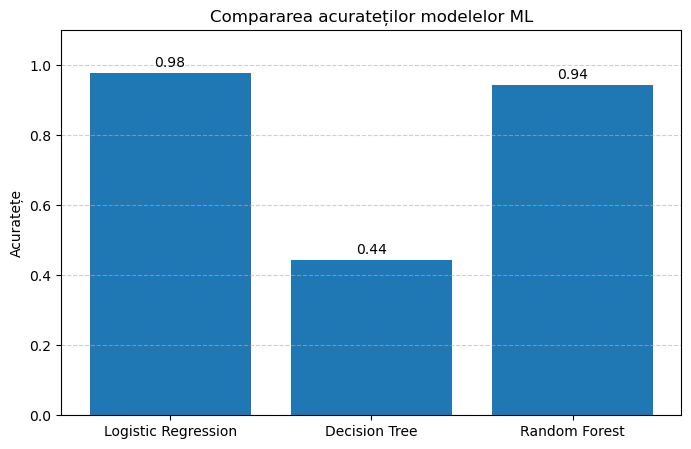

In [12]:
import matplotlib.pyplot as plt

# acuratetile obtinute
accuracies = [lr_accuracy, dt_accuracy, rf_accuracy]
model_names = ["Logistic Regression", "Decision Tree", "Random Forest"]

# cream graficul
plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies)

# adaugam etichete cu valori rotunjite pentru bare
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01,
             f"{height:.2f}", ha='center', va='bottom')

# stilizare
plt.ylim(0, 1.1)
plt.title("Compararea acurateților modelelor ML")
plt.ylabel("Acuratețe")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# afisare
plt.show()


## Interpretarea rezultatelor

După rularea celor trei modele, am obținut următoarele acurateți:

- Logistic Regressionsion **97.66%**
- Decision Tree **44.26%**
- Random Forest **94.38%**

---

### Interpretare:

 **Logistic Regression** are cea mai bună performanță în cazul nostru, ceea ce înseamnă că:
- Datele sunt relativ bine separate liniar
- Modelul reușește să învețe clar relația dintre nutrienți, climă și cultură

 **Random Forest** are o acuratețe foarte bună, aproape de Logistic Regression.
- Este un model mai complex și mai robust
- Poate fi mai potrivit în cazuri unde datele nu sunt perfect liniare

 **Decision Tree** are acuratețea cea mai scăzută
- E sensibil la date și poate face overfitting sau underfitting ușor
- Poate fi îmbunătățit cu ajustări (pruning, adâncime maximă etc.)

---

###  Concluzie:

Pentru acest set de date, **Logistic Regression** este cea mai eficientă alegere – oferă performanță excelentă cu o implementare simplă. Totuși, **Random Forest** rămâne o alternativă solidă, mai ales pentru date mai complexe.



## Utilizarea unui Data Pipeline

Pentru această etapă, am folosit un **Pipeline Spark MLlib** pentru a automatiza procesul de prelucrare și învățare automată.

Spre deosebire de varianta manuală, în care fiecare pas trebuie aplicat separat (transformarea etichetei, crearea vectorului de intrare, antrenarea modelului), un pipeline ne permite să definim toți acești pași într-un singur obiect. Astfel, întregul flux este mai clar, mai modular și mai ușor de reutilizat sau extins.

Mai jos avem un exemplu de utilizare de pipeline cu metoda logistic regression, toate datele mai puțin `evaluate` fiind reinitializate.

Observăm că varianta cu pipeline oferă exact aceleași rezultate ca cea fără pipeline: **97.66%** acuratețe.


In [15]:
from pyspark.ml import Pipeline

# refacem impartirea din datele curate
train_data, test_data = df_clean.randomSplit([0.8, 0.2], seed=1)

# definim (iar) pasii pipeline-ului
indexer = StringIndexer(inputCol="label", outputCol="labelIndex")
assembler = VectorAssembler(
    inputCols=["N", "P", "K", "temperature", "humidity", "ph", "rainfall"],
    outputCol="features"
)
lr = LogisticRegression(featuresCol="features", labelCol="labelIndex")

# cream pipeline-ul
pipeline = Pipeline(stages=[indexer, assembler, lr])

# antrenam pipeline-ul
pipeline_model = pipeline.fit(train_data)

# facem predictii pe test
predictions = pipeline_model.transform(test_data)

# evaluam acuratetea
# evaluatorul definit mai sus
accuracy = evaluator.evaluate(predictions)

print("Acuratețea pipeline-ului cu Logistic Regression:", round(accuracy, 4))


Acuratețea pipeline-ului cu Logistic Regression: 0.9766
